# Plummer Sphere Stability Test — bonsai_simple GPU Tree Code

Simulates an isolated Plummer cluster in realistic units **(kpc, km/s, M☉)**.

| Unit | Value |
|------|-------|
| length | 1 kpc |
| velocity | 1 km/s |
| mass | 1 M☉ |
| time | 1 kpc/(km/s) ≈ 0.978 Gyr |
| G | 4.3009 × 10⁻⁶ kpc (km/s)² M☉⁻¹ |

**Integration:** KDK leapfrog (half kick → drift → force → half kick).  
Positions and velocities are synchronised at every integer step — no drift correction needed.  
Energy diagnostics: KE = ½Σmᵢvᵢ², PE = ½Σmᵢφᵢ (φ from tree), E = KE + PE.

In [2]:
import sys, os, time
import numpy as np
import cupy as cp
import agama
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
from tqdm.auto import trange

# ── Locate bonsai_simple/ (per-particle eps, NOT the parent bonsai_modern/) ─
# Fingerprint: libtreeGPU.so AND test_comprehensive.py must both exist.
# bonsai_modern/ also has libtreeGPU.so but NOT test_comprehensive.py,
# so this reliably distinguishes the two regardless of CWD.
_cwd = os.path.abspath(".")
SIMPLE_DIR = next(
    (d for d in [os.path.join(_cwd, "bonsai_simple"), _cwd]
     if os.path.exists(os.path.join(d, "libtreeGPU.so"))
     and os.path.exists(os.path.join(d, "test_comprehensive.py"))),
    None,
)
if SIMPLE_DIR is None:
    raise FileNotFoundError(
        "Cannot find bonsai_simple/ (need libtreeGPU.so + test_comprehensive.py). "
        "Run 'make' inside bonsai_simple/ first.")
print(f"bonsai_simple found at: {SIMPLE_DIR}")

# Purge any stale bonsai_modern/tree_gpu already cached in sys.modules,
# then pin bonsai_simple/ at the front of sys.path.
for _k in list(sys.modules.keys()):
    if _k == "tree_gpu":
        _f = getattr(sys.modules[_k], "__file__", "") or ""
        if "bonsai_simple" not in _f:
            del sys.modules[_k]
if SIMPLE_DIR in sys.path:
    sys.path.remove(SIMPLE_DIR)
sys.path.insert(0, SIMPLE_DIR)
from tree_gpu import tree_gravity_gpu, TreeGPU, G_DEFAULT
print(f"tree_gpu loaded from: {tree_gravity_gpu.__globals__['__file__']}")

# ── Agama units: kpc, km/s, Msun ────────────────────────────────────────────
agama.setUnits(length=1, velocity=1, mass=1)
G   = G_DEFAULT          # 4.3009e-6 kpc (km/s)^2 / Msun
GYR = 0.97779             # kpc/(km/s) per Gyr
print(f"G = {G:.6e}  kpc (km/s)^2 Msun^-1")

bonsai_simple found at: /home/aarora/packages/bonsai_modern/bonsai_simple
tree_gpu loaded from: /home/aarora/packages/bonsai_modern/bonsai_simple/tree_gpu.py
G = 4.300917e-06  kpc (km/s)^2 Msun^-1


## Parameters

In [11]:
# ── Cluster ──────────────────────────────────────────────────────────────────
M_tot   = 1.0e6    # [Msun]   total cluster mass
r_s     = 0.01     # [kpc]    Plummer scale radius  (10 pc)
N       = 100_000  # number of equal-mass tracer particles
eps     = 0.0003    # [kpc]    Plummer softening length  (1 pc)

# ── Tree ─────────────────────────────────────────────────────────────────────
theta   = 0.5     # opening angle  (0.75 = fast; 0.5 = accurate)

# ── Integrator ───────────────────────────────────────────────────────────────
dt      = 2e-5     # [kpc/(km/s)]  ≈ t_cross / 60  ≈ 0.039 Myr
N_steps = 3000     # total steps   → t_total ≈ 58 Myr ≈ 50 t_cross
e_every = 300      # energy output every this many steps  (10 snapshots)

# ── Derived ──────────────────────────────────────────────────────────────────
sigma2  = G * M_tot / (6 * r_s)          # velocity dispersion² at r_s  [km/s]²
sigma   = sigma2**0.5
t_cross = r_s / sigma                    # crossing time  [kpc/(km/s)]
t_total = N_steps * dt

print(f"σ(r_s)   = {sigma:.2f} km/s")
print(f"t_cross  = {t_cross*1e3/GYR:.2f} Myr   ({t_cross:.3e} kpc/(km/s))")
print(f"dt       = {dt*1e3/GYR:.3f} Myr = t_cross / {t_cross/dt:.0f}")
print(f"t_total  = {t_total*1e3/GYR:.1f} Myr = {t_total/t_cross:.0f} t_cross")
print(f"eps      = {eps*1e3:.0f} pc = r_s / {r_s/eps:.0f}")
print(f"~runtime = {N_steps * 25e-3:.0f} s  (at 25 ms/step)")

σ(r_s)   = 8.47 km/s
t_cross  = 1.21 Myr   (1.181e-03 kpc/(km/s))
dt       = 0.020 Myr = t_cross / 59
t_total  = 61.4 Myr = 51 t_cross
eps      = 0 pc = r_s / 33
~runtime = 75 s  (at 25 ms/step)


## Sample initial conditions with Agama

In [12]:
c_pot = agama.Potential(type='plummer', scaleRadius=r_s, mass=M_tot)
c_df  = agama.DistributionFunction(type='quasispherical', potential=c_pot)
c_gm  = agama.GalaxyModel(c_pot, c_df)

print(f"Sampling {N:,} particles from Plummer DF ... ", end="", flush=True)
t0 = time.perf_counter()
xv_np, m_np = c_gm.sample(N)        # xv: (N,6)  x,y,z,vx,vy,vz; m: (N,)
print(f"done in {time.perf_counter()-t0:.1f} s")

m_np = m_np.astype(np.float32)
xv_np = xv_np.astype(np.float32)

# ── CoM correction (sampling noise can give non-zero CoM vel) ────────────────
m_tot_samp = m_np.sum()
r_com = (m_np[:, None] * xv_np[:, :3]).sum(0) / m_tot_samp
v_com = (m_np[:, None] * xv_np[:, 3:]).sum(0) / m_tot_samp
xv_np[:, :3] -= r_com
xv_np[:, 3:] -= v_com
print(f"CoM position  shift: {np.linalg.norm(r_com):.3e} kpc")
print(f"CoM velocity  shift: {np.linalg.norm(v_com):.3e} km/s")

# ── Transfer to GPU ──────────────────────────────────────────────────────────
pos0  = cp.asarray(xv_np[:, :3])    # (N, 3) float32
vel0  = cp.asarray(xv_np[:, 3:])    # (N, 3) float32
mass  = cp.asarray(m_np)            # (N,)   float32
eps_a = cp.full(N, eps, dtype=cp.float32)

# store initial positions as numpy for later plotting
pos0_np = xv_np[:, :3].copy()

r_half_samp = float(cp.median(cp.linalg.norm(pos0, axis=1)))
v_rms_samp  = float(cp.sqrt(cp.mean(cp.sum(vel0**2, axis=1))))
print(f"\nr_half (sampled)   = {r_half_samp*1e3:.2f} pc")
print(f"v_rms  (sampled)   = {v_rms_samp:.2f} km/s  (expect ~{sigma:.2f})")
print(f"particle mass      = {float(mass[0]):.3e} Msun")

Sampling 100,000 particles from Plummer DF ... done in 0.2 s
CoM position  shift: 8.211e-05 kpc
CoM velocity  shift: 3.442e-02 km/s

r_half (sampled)   = 13.09 pc
v_rms  (sampled)   = 11.23 km/s  (expect ~8.47)
particle mass      = 1.000e+01 Msun


## Integrator

```
nbody_simulate(posvel, mass, eps, solver, solver_args)
```

Dispatches to the requested solver.  
`solver='kdk'` implements the KDK Leapfrog (Kick-Drift-Kick):

```
v(n+½) = v(n) + ½ dt a(n)       # half kick
x(n+1) = x(n) + dt v(n+½)       # drift
a(n+1) = tree_force(x(n+1))     # tree call  ← bulk of runtime
v(n+1) = v(n+½) + ½ dt a(n+1)  # half kick
```

x and v are synchronised at every integer step → energy is always well-defined.

In [13]:
def nbody_simulate(posvel, mass, eps,
                   solver='kdk',
                   solver_args=None):
    """
    Run an N-body simulation using the bonsai_simple GPU tree code.

    Parameters
    ----------
    posvel : cp.ndarray, shape (N, 6)  float32
        Initial conditions [x, y, z, vx, vy, vz] in kpc / km/s.
    mass   : cp.ndarray, shape (N,)   float32
        Particle masses [Msun].
    eps    : float or cp.ndarray, shape (N,)
        Plummer softening length(s) [kpc].  Scalar or per-particle array.
    solver : str
        'kdk'  — KDK leapfrog (only option for now).
    solver_args : dict, optional
        Keys consumed by the solver:
          dt      [kpc/(km/s)]  timestep
          n_steps              number of integration steps
          e_every              energy output interval (steps)
          G       float        gravitational constant (default: G_DEFAULT)
          theta   float        B-H opening angle     (default: 0.75)
          verbose bool         print tree timing     (default: False)

    Returns
    -------
    posvel_f : cp.ndarray (N, 6)   final positions + velocities
    diag     : dict with keys
        t_arr   (n_e,) float64  time of each energy snapshot  [kpc/(km/s)]
        KE_arr  (n_e,) float64  kinetic energy                [Msun (km/s)^2]
        PE_arr  (n_e,) float64  potential energy (< 0)
        E_arr   (n_e,) float64  total energy
    """
    if solver != 'kdk':
        raise NotImplementedError(f"solver='{solver}' not implemented; use 'kdk'")
    args     = solver_args or {}
    dt_s     = float(args.get('dt',      4e-5))
    n_steps  = int(  args.get('n_steps', 1500))
    e_every_ = int(  args.get('e_every', 150))
    G_s      = float(args.get('G',       G_DEFAULT))
    theta_s  = float(args.get('theta',   0.75))
    verbose_ = bool( args.get('verbose', False))

    N = posvel.shape[0]
    pos = cp.ascontiguousarray(posvel[:, :3])
    vel = cp.ascontiguousarray(posvel[:, 3:])

    # allocate tree once — avoids ~27 ms malloc per step
    tree = TreeGPU(N, eps=0.0, theta=theta_s, verbose=verbose_)

    def _energy(vel_sync, phi_sync):
        """KE + PE at synchronised (x, v) — exact for KDK."""
        v2  = cp.sum(vel_sync.astype(cp.float64)**2, axis=1)
        KE  = 0.5 * float(cp.sum(mass.astype(cp.float64) * v2))
        PE  = 0.5 * float(cp.sum(mass.astype(cp.float64) * phi_sync.astype(cp.float64)))
        return KE, PE

    # ── initial force ────────────────────────────────────────────────────────
    acc, phi = tree_gravity_gpu(pos, mass, eps, G=G_s, theta=theta_s, tree=tree)

    # ── energy storage ───────────────────────────────────────────────────────
    n_e   = n_steps // e_every_ + 1
    t_arr = np.zeros(n_e)
    KE_np = np.zeros(n_e)
    PE_np = np.zeros(n_e)
    E_np  = np.zeros(n_e)

    KE0, PE0 = _energy(vel, phi)
    t_arr[0] = 0.0;  KE_np[0] = KE0;  PE_np[0] = PE0;  E_np[0] = KE0 + PE0
    e_idx = 1

    # ── KDK loop ─────────────────────────────────────────────────────────────
    t_wall0 = time.perf_counter()
    for step in trange(n_steps):
        vel  = vel  + (0.5 * dt_s) * acc       # ½ kick
        pos  = pos  + dt_s         * vel        # drift
        acc, phi = tree_gravity_gpu(
            pos, mass, eps, G=G_s, theta=theta_s, tree=tree)
        vel  = vel  + (0.5 * dt_s) * acc       # ½ kick

        if (step + 1) % e_every_ == 0 and e_idx < n_e:
            KE, PE = _energy(vel, phi)
            t_arr[e_idx] = (step + 1) * dt_s
            KE_np[e_idx] = KE
            PE_np[e_idx] = PE
            E_np [e_idx] = KE + PE
            dE_rel = (E_np[e_idx] - E_np[0]) / abs(E_np[0])
            elapsed = time.perf_counter() - t_wall0
            eta     = elapsed / (step + 1) * (n_steps - step - 1)
            print(f"  step {step+1:5d}/{n_steps}  "
                  f"t={t_arr[e_idx]*1e3/GYR:6.1f} Myr  "
                  f"KE={KE:.4e}  PE={PE:.4e}  "
                  f"ΔE/E={dE_rel:+.2e}  "
                  f"ETA {eta:.0f} s", flush=True)
            e_idx += 1

    tree.close()
    print(f"\nDone. Wall time: {time.perf_counter()-t_wall0:.1f} s")

    posvel_f = cp.concatenate([pos, vel], axis=1)
    return posvel_f, dict(
        t_arr  = t_arr[:e_idx],
        KE_arr = KE_np[:e_idx],
        PE_arr = PE_np[:e_idx],
        E_arr  = E_np [:e_idx],
    )

## Run simulation

In [14]:
%%timeit
tree_gravity_gpu(pos0, mass, eps=eps_a)

38.3 ms ± 1.75 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
# pack initial state as (N, 6)
posvel0 = cp.concatenate([pos0, vel0], axis=1)

print(f"Running KDK leapfrog: N={N:,}  N_steps={N_steps:,}  dt={dt*1e3/GYR:.3f} Myr")
print(f"theta={theta}  eps={eps*1e3:.0f} pc  t_total={N_steps*dt*1e3/GYR:.1f} Myr")
print()

posvel_f, diag = nbody_simulate(
    posvel0, mass, eps_a,
    solver='kdk',
    solver_args=dict(
        dt      = dt,
        n_steps = N_steps,
        e_every = e_every,
        G       = G,
        theta   = theta,
        verbose = False,
    ),
)

Running KDK leapfrog: N=100,000  N_steps=3,000  dt=0.020 Myr
theta=0.5  eps=0 pc  t_total=61.4 Myr



  0%|          | 0/3000 [00:00<?, ?it/s]

  step   300/3000  t=   6.1 Myr  KE=6.2560e+07  PE=-1.2557e+08  ΔE/E=+2.80e-06  ETA 70 s
  step   600/3000  t=  12.3 Myr  KE=6.2411e+07  PE=-1.2542e+08  ΔE/E=+1.65e-06  ETA 62 s
  step   900/3000  t=  18.4 Myr  KE=6.2598e+07  PE=-1.2561e+08  ΔE/E=+2.24e-06  ETA 54 s
  step  1200/3000  t=  24.5 Myr  KE=6.2553e+07  PE=-1.2557e+08  ΔE/E=+5.19e-06  ETA 46 s
  step  1500/3000  t=  30.7 Myr  KE=6.2636e+07  PE=-1.2565e+08  ΔE/E=+4.55e-08  ETA 38 s
  step  1800/3000  t=  36.8 Myr  KE=6.2570e+07  PE=-1.2558e+08  ΔE/E=-2.42e-06  ETA 30 s
  step  2100/3000  t=  43.0 Myr  KE=6.2985e+07  PE=-1.2600e+08  ΔE/E=-3.69e-06  ETA 23 s
  step  2400/3000  t=  49.1 Myr  KE=6.2444e+07  PE=-1.2546e+08  ΔE/E=+6.45e-06  ETA 15 s
  step  2700/3000  t=  55.2 Myr  KE=6.2332e+07  PE=-1.2534e+08  ΔE/E=+3.25e-06  ETA 8 s
  step  3000/3000  t=  61.4 Myr  KE=6.2605e+07  PE=-1.2562e+08  ΔE/E=-1.60e-06  ETA 0 s

Done. Wall time: 75.9 s


## Energy conservation

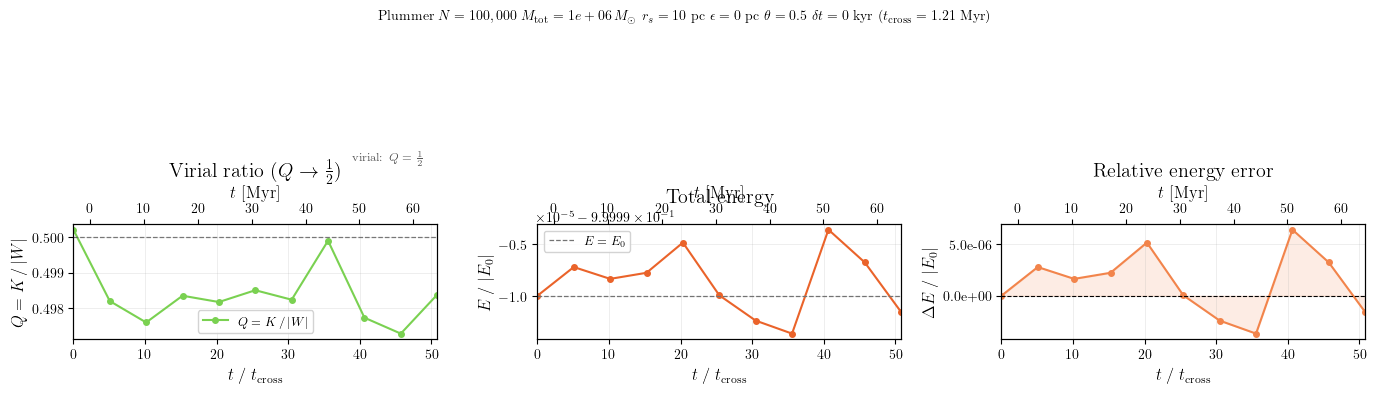

Delta-E/E  (final)       = -1.596e-06   (< 1e-3 is good for theta=0.5)
Q = K/|W|  (mean)        = 0.4984   (virial equilibrium: Q = 0.5000)
Note: K/|E| = 0.9937  ~1 (correct; E = -K at virial equil.)
t_cross = 1.208 Myr,  t_total = 50.8 t_cross


In [16]:
try:
    import cmasher as cmr
    _cmap_init  = cmr.ocean_r
    _cmap_final = cmr.ember
    _lc_init    = '#d4f0f0'
    _lc_final   = '#fff0c0'
except ImportError:
    _cmap_init  = 'viridis'
    _cmap_final = 'plasma'
    _lc_init    = 'w'
    _lc_final   = 'w'

t_tc         = diag['t_arr'] / t_cross      # t in units of t_cross
t_cross_Myr  = t_cross * 1e3 / GYR
E0           = diag['E_arr'][0]
dE_rel       = (diag['E_arr'] - E0) / abs(E0)

# ── virial ratio Q = K / |W|  (= K / |PE|)
#    virial theorem: 2K = |W|  →  Q = 0.5 at equilibrium
#    (NOT K/|E|, which equals 1.0 at equilibrium because E = -K)
Q_arr = diag['KE_arr'] / np.abs(diag['PE_arr'])

_c_Q   = plt.cm.viridis(0.80)
_c_W   = plt.cm.viridis(0.30)
_c_E   = plt.cm.inferno(0.65)
_c_dE  = plt.cm.plasma(0.70)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def _add_top_myr_axis(ax):
    ax2 = ax.twiny()
    ax2.set_xlim(np.array(ax.get_xlim()) * t_cross_Myr)
    ax2.set_xlabel(r'$t$ [Myr]')
    return ax2

# ── (a)  Virial ratio  Q = K / |W| ──────────────────────────────────────────
ax = axes[0]
ax.plot(t_tc, Q_arr, '-o', color=_c_Q, ms=4, label=r'$Q = K\,/\,|W|$')
ax.axhline(0.5, color='0.35', ls='--', lw=0.9, alpha=0.8)
ax.text(t_tc[-1] * 0.96, 0.502,
        r'virial: $Q = \frac{1}{2}$',
        ha='right', va='bottom', fontsize=8.5, color='0.35')
ax.set_xlabel(r'$t\;/\;t_{\rm cross}$')
ax.set_ylabel(r'$Q = K\,/\,|W|$')
ax.set_title(r'Virial ratio  $(Q \to \frac{1}{2})$')
ax.legend(framealpha=0.85, fontsize=9)
_add_top_myr_axis(ax)

# ── (b)  Total energy ────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(t_tc, diag['E_arr'] / abs(E0), '-o', color=_c_E, ms=4)
ax.axhline(-1.0, color='0.45', ls='--', lw=0.9,
           label=r'$E = E_0$')
ax.set_xlabel(r'$t\;/\;t_{\rm cross}$')
ax.set_ylabel(r'$E\;/\;|E_0|$')
ax.set_title(r'Total energy')
ax.legend(framealpha=0.85, fontsize=9)
_add_top_myr_axis(axes[1])

# ── (c)  Relative energy error ───────────────────────────────────────────────
ax = axes[2]
ax.plot(t_tc, dE_rel, '-o', color=_c_dE, ms=4)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.fill_between(t_tc, dE_rel, alpha=0.15, color=_c_dE)
ax.set_xlabel(r'$t\;/\;t_{\rm cross}$')
ax.set_ylabel(r'$\Delta E\;/\;|E_0|$')
ax.set_title(r'Relative energy error')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1e}'))
_add_top_myr_axis(axes[2])

for ax in axes:
    ax.set_xlim(t_tc[0], t_tc[-1])
    ax.grid(True, alpha=0.25, lw=0.6)

title = (rf"Plummer  $N={N:,}$  "
         rf"$M_\mathrm{{tot}}={M_tot:.0e}\,M_\odot$  "
         rf"$r_s={r_s*1e3:.0f}$ pc  "
         rf"$\epsilon={eps*1e3:.0f}$ pc  "
         rf"$\theta={theta}$  "
         rf"$\delta t = {dt*1e3/GYR:.0f}$ kyr  "
         rf"($t_\mathrm{{cross}} = {t_cross_Myr:.2f}$ Myr)")
plt.suptitle(title, fontsize=10)
plt.tight_layout()
plt.show()

# ── summary diagnostics ──────────────────────────────────────────────────────
Q_mean = float(np.mean(Q_arr))
print(f"Delta-E/E  (final)       = {dE_rel[-1]:+.3e}   (< 1e-3 is good for theta={theta})")
print(f"Q = K/|W|  (mean)        = {Q_mean:.4f}   (virial equilibrium: Q = 0.5000)")
print(f"Note: K/|E| = {np.mean(diag['KE_arr'])/abs(E0):.4f}  ~1 (correct; E = -K at virial equil.)")
print(f"t_cross = {t_cross_Myr:.3f} Myr,  t_total = {t_tc[-1]:.1f} t_cross")

## Initial vs final spatial distribution

Filled contours (closed inner iso-density) + line contours (open outer).  
Positions are recentred on the mass-weighted CoM before plotting.

r_half (initial) = 13.09 pc
r_half (final)   = 13.14 pc
Plot range       +/- 65.7 pc


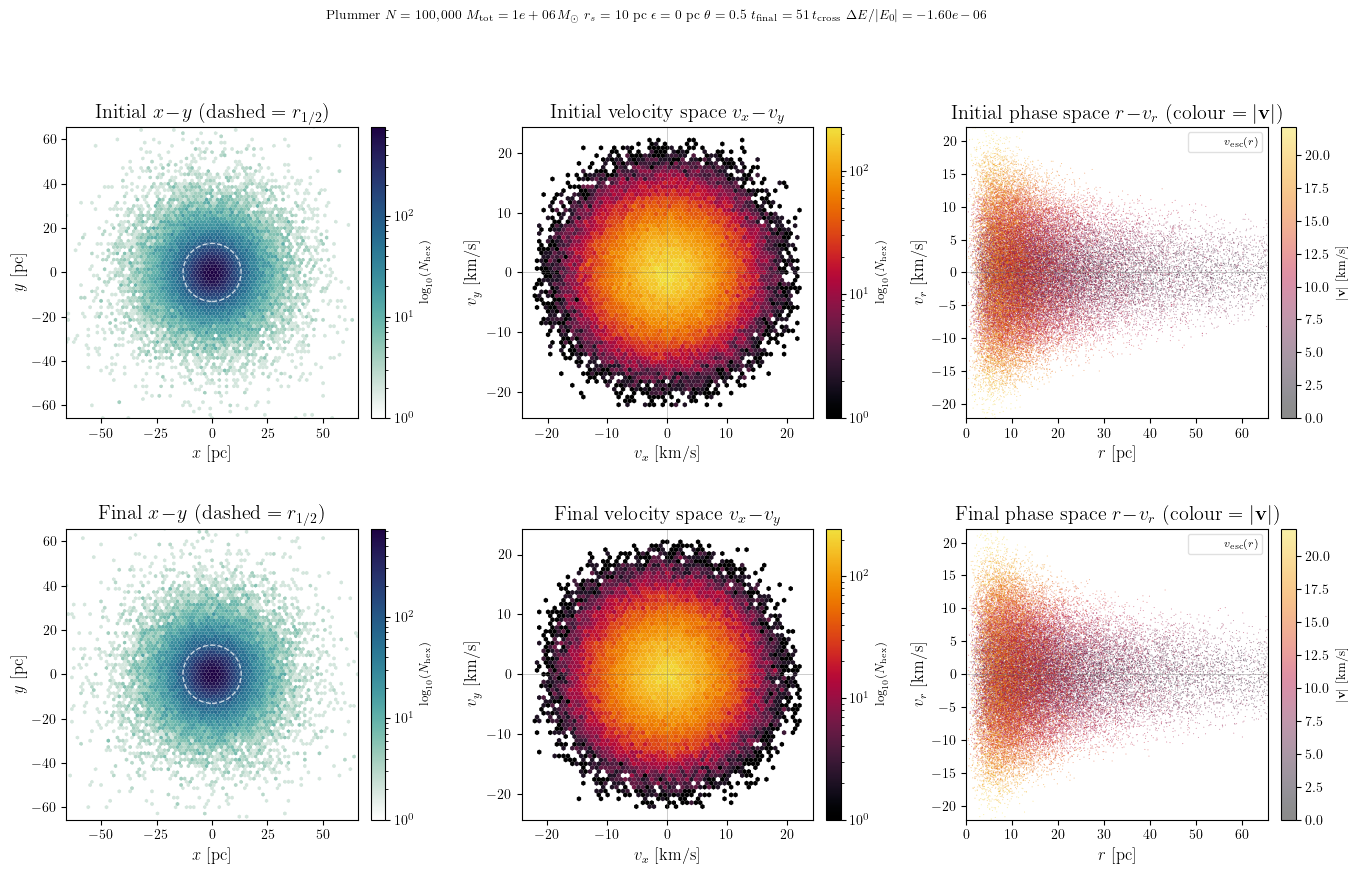

Delta r_half / r_half_0 = +0.0037


: 

In [ ]:
try:
    import cmasher as cmr
    _cm_pos = cmr.ocean_r    # position density
    _cm_phs = cmr.ember      # velocity / phase space
except ImportError:
    _cm_pos = 'viridis'
    _cm_phs = 'plasma'

# ── numpy copies ─────────────────────────────────────────────────────────────
mass_np  = cp.asnumpy(mass)
vel0_np  = cp.asnumpy(vel0)                 # initial velocities (unchanged by sim)
pos_f_np = cp.asnumpy(posvel_f[:, :3])
velf_np  = cp.asnumpy(posvel_f[:, 3:])

def _recentre(pos_kpc, m):
    com = (m[:, None] * pos_kpc).sum(0) / m.sum()
    return pos_kpc - com

pos0_rc = _recentre(pos0_np,  mass_np)     # kpc
posf_rc = _recentre(pos_f_np, mass_np)

r_half_0 = np.median(np.linalg.norm(pos0_rc, axis=1))
r_half_f = np.median(np.linalg.norm(posf_rc, axis=1))
lim_pc   = 5.0 * max(r_half_0, r_half_f) * 1e3   # plot range  [pc]

print(f"r_half (initial) = {r_half_0*1e3:.2f} pc")
print(f"r_half (final)   = {r_half_f*1e3:.2f} pc")
print(f"Plot range       +/- {lim_pc:.1f} pc")

# ── Plummer escape velocity envelope for phase-space panel ───────────────────
r_th_pc  = np.linspace(0.1, lim_pc, 400)
v_esc_th = np.sqrt(2 * G * M_tot / np.sqrt((r_th_pc * 1e-3)**2 + r_s**2))  # km/s

# ── 2 × 3 figure ─────────────────────────────────────────────────────────────
#   col 0: x-y hexbin  (log density)
#   col 1: vx-vy hexbin (velocity space)
#   col 2: r-vr scatter (phase space, coloured by speed)
fig, axes = plt.subplots(2, 3, figsize=(16, 9),
                         gridspec_kw={'wspace': 0.38, 'hspace': 0.38})

_rng = np.random.default_rng(42)

CONFIGS = [
    ('Initial', pos0_rc, vel0_np,  r_half_0),
    ('Final',   posf_rc, velf_np,  r_half_f),
]

for row, (label, pos_rc, vel_np, r_hm) in enumerate(CONFIGS):

    # positions in pc
    xp = pos_rc[:, 0] * 1e3
    yp = pos_rc[:, 1] * 1e3
    zp = pos_rc[:, 2] * 1e3

    vx = vel_np[:, 0]    # km/s
    vy = vel_np[:, 1]
    vz = vel_np[:, 2]
    spd = np.sqrt(vx**2 + vy**2 + vz**2)

    # radial velocity  vr = r_hat · v
    r3_kpc = np.linalg.norm(pos_rc, axis=1)
    r3_kpc = np.where(r3_kpc > 0, r3_kpc, 1e-30)
    r_hat  = pos_rc / r3_kpc[:, None]
    vr     = (r_hat * vel_np).sum(axis=1)   # km/s
    rp_pc  = r3_kpc * 1e3                   # pc

    v_lim = float(np.percentile(spd, 99.5))

    # ── col 0: x-y position, hexbin log density ───────────────────────────────
    ax = axes[row, 0]
    hb = ax.hexbin(xp, yp,
                   gridsize=80, bins='log', cmap=_cm_pos,
                   mincnt=1, linewidths=0.0,
                   extent=[-lim_pc, lim_pc, -lim_pc, lim_pc])
    cb = plt.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(r'$\log_{10}(N_{\rm hex})$', fontsize=9)
    circ = plt.Circle((0, 0), r_hm * 1e3,
                       fill=False, ls='--', lw=1.0, color='w', alpha=0.75)
    ax.add_patch(circ)
    ax.set_aspect('equal')
    ax.set_xlim(-lim_pc, lim_pc); ax.set_ylim(-lim_pc, lim_pc)
    ax.set_xlabel(r'$x$ [pc]'); ax.set_ylabel(r'$y$ [pc]')
    ax.set_title(rf'{label}  $x\!-\!y$  (dashed $= r_{{1/2}}$)')

    # ── col 1: vx-vy velocity space, hexbin log density ──────────────────────
    ax = axes[row, 1]
    hb2 = ax.hexbin(vx, vy,
                    gridsize=60, bins='log', cmap=_cm_phs,
                    mincnt=1, linewidths=0.0,
                    extent=[-v_lim, v_lim, -v_lim, v_lim])
    cb2 = plt.colorbar(hb2, ax=ax, fraction=0.046, pad=0.04)
    cb2.set_label(r'$\log_{10}(N_{\rm hex})$', fontsize=9)
    ax.set_aspect('equal')
    ax.axhline(0, color='0.45', lw=0.5, alpha=0.5)
    ax.axvline(0, color='0.45', lw=0.5, alpha=0.5)
    ax.set_xlabel(r'$v_x$ [km/s]'); ax.set_ylabel(r'$v_y$ [km/s]')
    ax.set_title(rf'{label}  velocity space  $v_x\!-\!v_y$')

    # ── col 2: r-vr phase space, scatter coloured by speed ───────────────────
    ax = axes[row, 2]
    # subsample for scatter rendering speed (50 K is plenty)
    N_sc = min(len(rp_pc), 50_000)
    idx  = _rng.choice(len(rp_pc), N_sc, replace=False)
    # sort by speed so bright (fast) particles render on top
    ord_ = np.argsort(spd[idx])
    sc   = ax.scatter(rp_pc[idx][ord_], vr[idx][ord_],
                      c=spd[idx][ord_],
                      s=0.6, alpha=0.45, linewidths=0,
                      cmap=_cm_phs, vmin=0, vmax=v_lim,
                      rasterized=True)
    cb3 = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb3.set_label(r'$|\mathbf{v}|$ [km/s]', fontsize=9)
    # Plummer escape velocity envelope
    ax.plot( r_th_pc,  v_esc_th, color='w', ls='--', lw=1.0, alpha=0.8,
             label=r'$v_{\rm esc}(r)$')
    ax.plot( r_th_pc, -v_esc_th, color='w', ls='--', lw=1.0, alpha=0.8)
    ax.axhline(0, color='0.45', lw=0.5, alpha=0.5)
    ax.set_xlim(0, lim_pc); ax.set_ylim(-v_lim, v_lim)
    ax.set_xlabel(r'$r$ [pc]'); ax.set_ylabel(r'$v_r$ [km/s]')
    ax.set_title(rf'{label}  phase space  $r\!-\!v_r$  (colour $= |\mathbf{{v}}|$)')
    ax.legend(fontsize=8, framealpha=0.6, loc='upper right')

title = (rf"Plummer  $N={N:,}$  "
         rf"$M_\mathrm{{tot}}={M_tot:.0e}\,M_\odot$  "
         rf"$r_s={r_s*1e3:.0f}$ pc  "
         rf"$\epsilon={eps*1e3:.0f}$ pc  "
         rf"$\theta={theta}$  "
         rf"$t_\mathrm{{final}}={N_steps*dt/t_cross:.0f}\,t_\mathrm{{cross}}$  "
         rf"$\Delta E/|E_0|={dE_rel[-1]:+.2e}$")
fig.suptitle(title, fontsize=9.5, y=1.01)
plt.show()

print(f"Delta r_half / r_half_0 = {(r_half_f - r_half_0) / r_half_0:+.4f}")


## Half-mass radius evolution (optional)

Re-run at reduced output cadence if you want a smooth r_half(t) curve.  
As a quick proxy, snapshot every `e_every` steps and track the 50th percentile of |r|.

In [10]:
# This cell runs a *second* short simulation saving r_half every step.
# Set TRACK_RHALF = True to enable (adds ~15 s for N=100K, 200 steps).
TRACK_RHALF = False

if TRACK_RHALF:
    N_short  = 200
    rhalf_t  = np.zeros(N_short + 1)
    t_s      = np.zeros(N_short + 1)

    pos_s = pos0.copy()
    vel_s = vel0.copy()
    tree_s = TreeGPU(N, eps=0.0, theta=theta, verbose=False)
    acc_s, phi_s = tree_gravity_gpu(pos_s, mass, eps_a, G=G, theta=theta, tree=tree_s)

    rhalf_t[0] = float(cp.median(cp.linalg.norm(pos_s, axis=1)))
    for step in range(N_short):
        vel_s = vel_s + (0.5*dt) * acc_s
        pos_s = pos_s + dt * vel_s
        acc_s, phi_s = tree_gravity_gpu(pos_s, mass, eps_a, G=G, theta=theta, tree=tree_s)
        vel_s = vel_s + (0.5*dt) * acc_s
        rhalf_t[step+1] = float(cp.median(cp.linalg.norm(pos_s, axis=1)))
        t_s[step+1]     = (step+1) * dt
    tree_s.close()

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(t_s * 1e3 / GYR, rhalf_t * 1e3, 'C0-')
    ax.axhline(r_half_0 * 1e3, color='k', ls='--', lw=0.8, label='initial r_half')
    ax.set_xlabel('t  [Myr]')
    ax.set_ylabel('r_half  [pc]')
    ax.set_title('Half-mass radius evolution')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Set TRACK_RHALF = True to run the half-mass radius tracking cell.")

Set TRACK_RHALF = True to run the half-mass radius tracking cell.
